# Hello
### welcome to Aaron's Data analysis

Below I'm going to import the libraries that are necessary for this analysis

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.ops import unary_union
from datetime import datetime
from modules import utils, maps, histogram

#Helper functions to prepare the dataframes that we need
subway_stations_gdf, taxi_zones_gdf, subway_lines_gdf = utils.prepare_gdf_data()
hvfhv_df, mta_df = utils.prepare_ridership_data()

print(subway_stations_gdf.columns)
print(mta_df.columns)

Index(['Station ID', 'Complex ID', 'Line', 'Stop Name', 'Borough',
       'GTFS Latitude', 'GTFS Longitude', 'geometry'],
      dtype='str')
Index(['station_complex_id', 'date', 'ridership'], dtype='str')


Below is going to be a histogram for the riderships of the MTA and HVFHV data

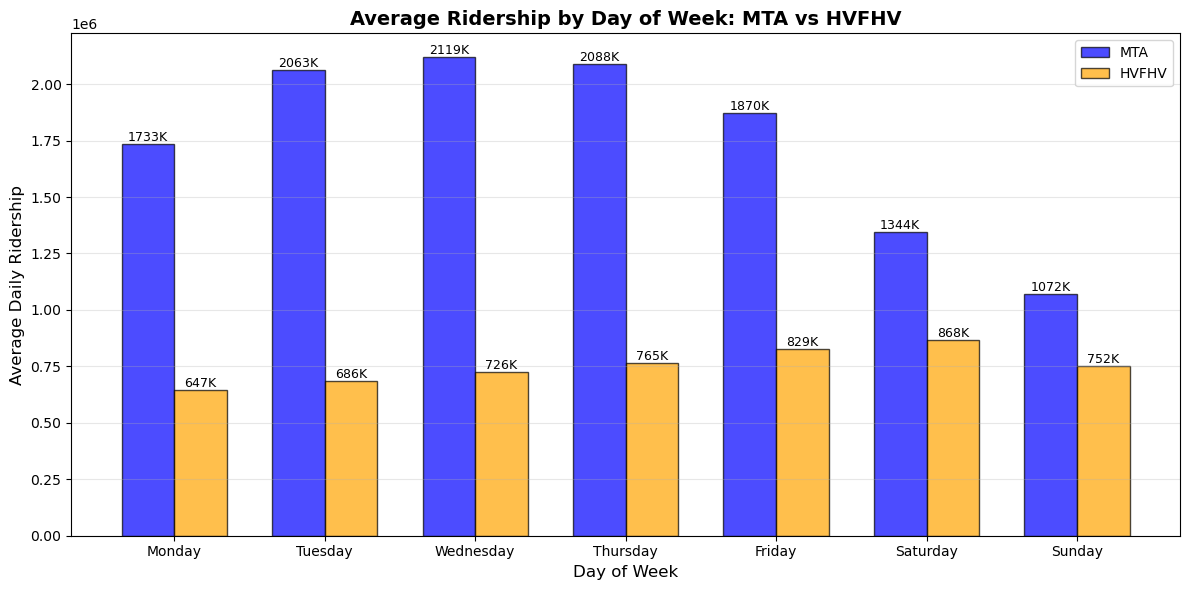

In [8]:
# Aggregate by date
mta_agg = mta_df.groupby('date').agg({'ridership': 'sum'}).reset_index()
hvfhv_agg = hvfhv_df.groupby('date').agg({'trip_count': 'sum'}).reset_index()


# Merge the datasets
merged_df = pd.merge(mta_agg, hvfhv_agg, on='date', how='inner')
merged_df.columns = ['date', 'mta_ridership', 'hvfhv_trips']
merged_df['date'] = pd.to_datetime(merged_df['date'])

# Add day of week
merged_df['day_of_week'] = merged_df['date'].dt.day_name()

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate average ridership by day of week
dow_avg = merged_df.groupby('day_of_week')[['mta_ridership', 'hvfhv_trips']].mean().reindex(day_order)


# Create the histogram
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(day_order))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, dow_avg['mta_ridership'], width, 
               label='MTA', color='blue', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, dow_avg['hvfhv_trips'], width, 
               label='HVFHV', color='orange', alpha=0.7, edgecolor='black')

# Customize the plot
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Daily Ridership', fontsize=12)
ax.set_title('Average Ridership by Day of Week: MTA vs HVFHV', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(day_order)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height/1000)}K', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


We're going to do a heatp of the ridership for the Taxi zones on wednesday, and Saturday

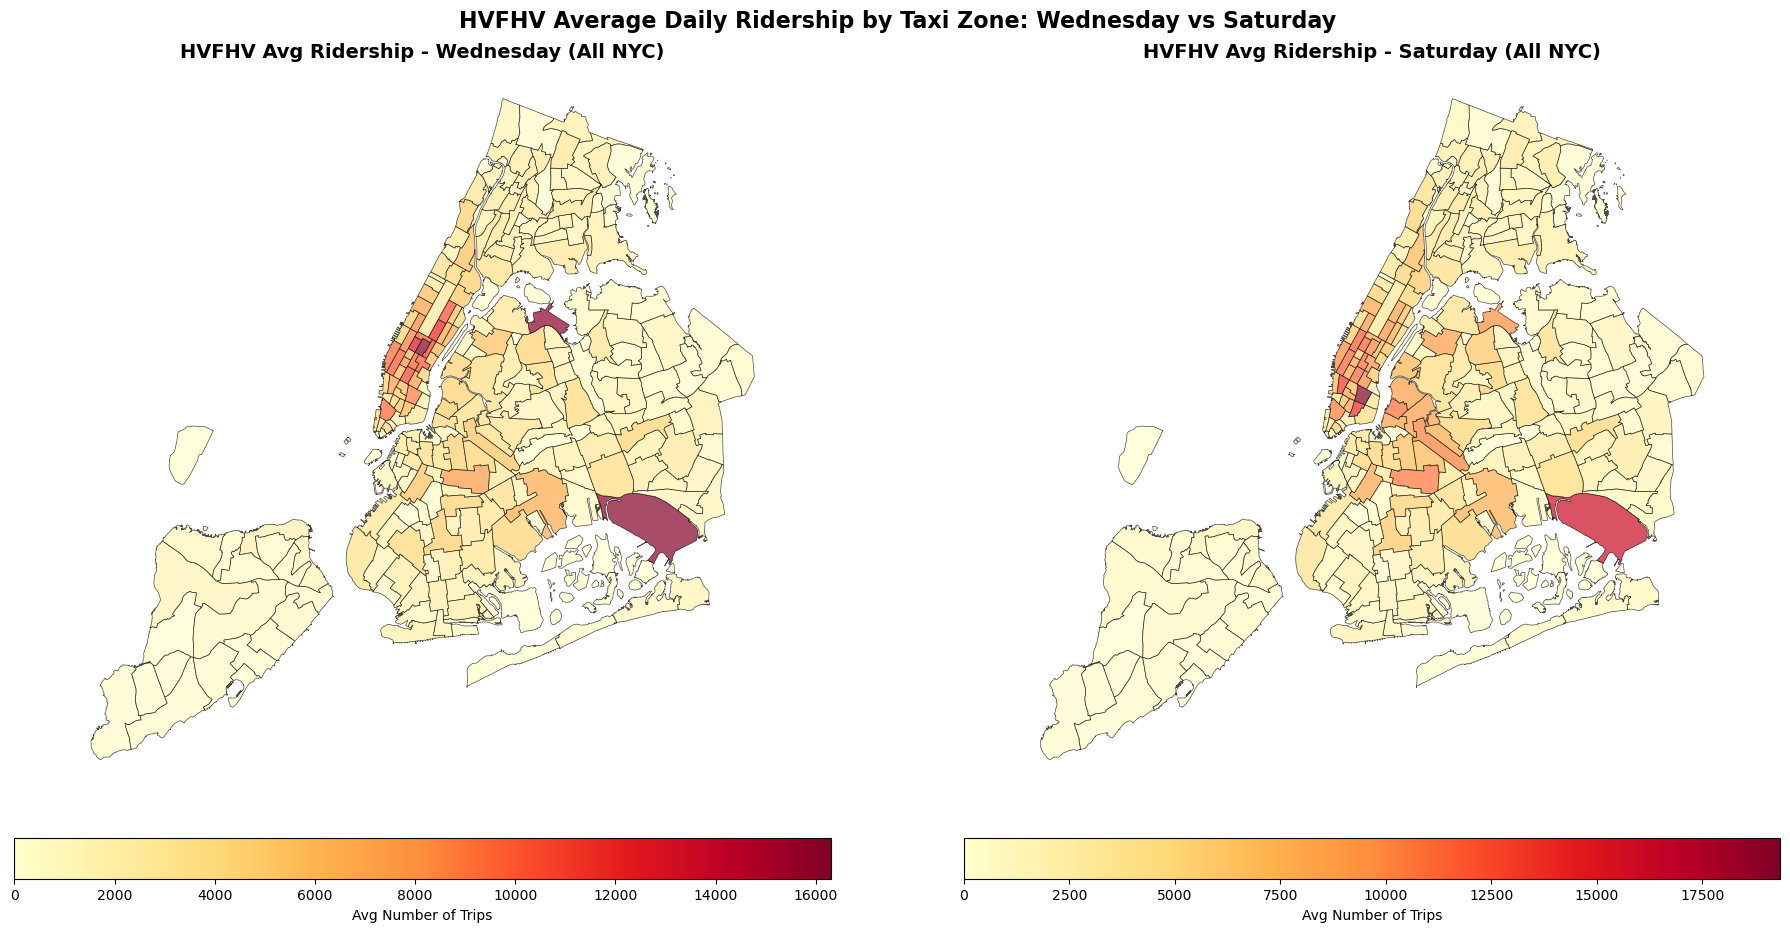

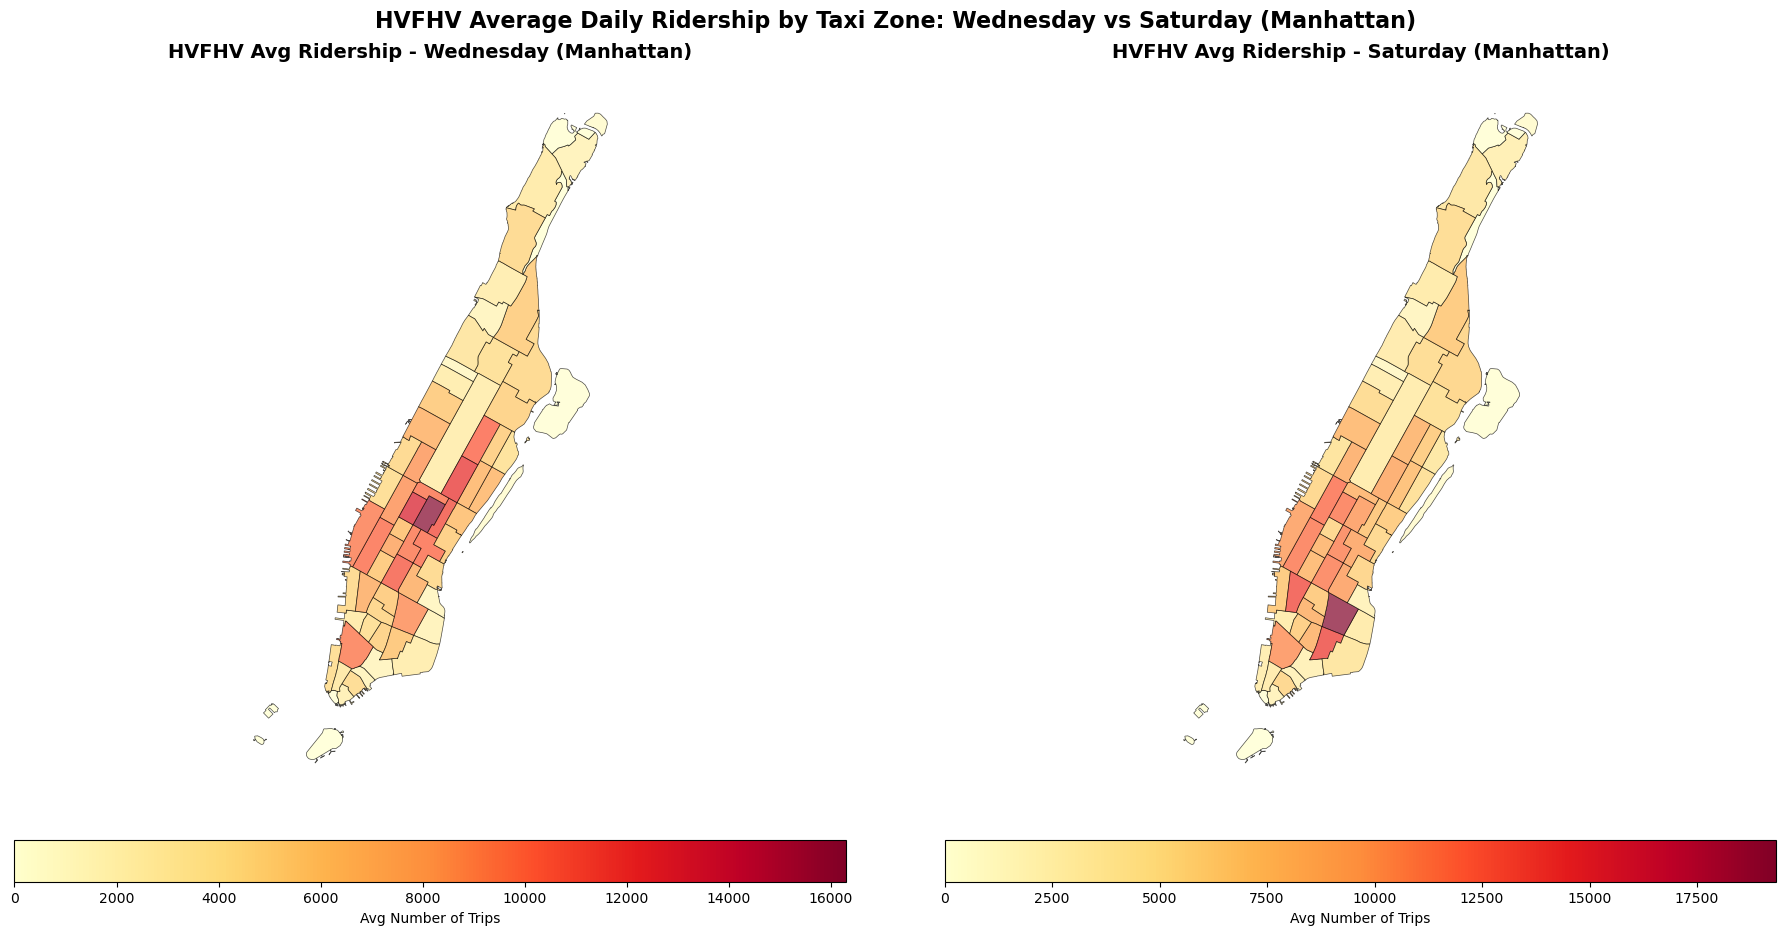

SUMMARY STATISTICS - ALL NYC (AVERAGES)
Number of Wednesdays in data: 52
Number of Saturdays in data: 52
Average Wednesday total trips: 726,798
Average Saturday total trips: 868,833
Saturday/Wednesday ratio: 1.20

SUMMARY STATISTICS - MANHATTAN ONLY (AVERAGES)
Average Wednesday Manhattan trips: 356,343
Average Saturday Manhattan trips: 409,062
Saturday/Wednesday ratio: 1.15
Manhattan % of NYC Wednesday: 49.0%
Manhattan % of NYC Saturday: 47.1%

TOP 10 ZONES BY AVERAGE RIDERSHIP - ALL NYC

Wednesday top zones:
  Midtown Center (Manhattan): 16,299 avg daily trips
  JFK Airport (Queens): 16,143 avg daily trips
  LaGuardia Airport (Queens): 15,936 avg daily trips
  Times Sq/Theatre District (Manhattan): 12,872 avg daily trips
  Upper East Side South (Manhattan): 11,958 avg daily trips
  Midtown East (Manhattan): 11,152 avg daily trips
  Union Sq (Manhattan): 10,707 avg daily trips
  Upper East Side North (Manhattan): 10,290 avg daily trips
  Murray Hill (Manhattan): 10,068 avg daily trips


In [42]:
"""
Heatmaps of ridership by taxi zone - Wednesday vs Saturday (AVERAGES)
"""

# Convert date and add day of week
hvfhv_df['date'] = pd.to_datetime(hvfhv_df['date'])
hvfhv_df['day_of_week'] = hvfhv_df['date'].dt.day_name()

taxi_zones_gdf['locationid'] = taxi_zones_gdf['locationid'].astype(str)
hvfhv_df['PULocationID'] = hvfhv_df['PULocationID'].astype(str)

# Filter for Wednesday and Saturday
wednesday_data = hvfhv_df[hvfhv_df['day_of_week'] == 'Wednesday']
saturday_data = hvfhv_df[hvfhv_df['day_of_week'] == 'Saturday']

# Calculate AVERAGE trips by location for each day (not sum)
wednesday_avg = wednesday_data.groupby('PULocationID').agg({
    'trip_count': 'mean'  # Changed from 'sum' to 'mean'
}).reset_index()
wednesday_avg.columns = ['PULocationID', 'avg_trip_count']

saturday_avg = saturday_data.groupby('PULocationID').agg({
    'trip_count': 'mean'  # Changed from 'sum' to 'mean'
}).reset_index()
saturday_avg.columns = ['PULocationID', 'avg_trip_count']

# Merge with taxi zones
zones_wed = taxi_zones_gdf.merge(wednesday_avg, left_on='locationid', right_on='PULocationID', how='left')
zones_wed['avg_trip_count'] = zones_wed['avg_trip_count'].fillna(0)

zones_sat = taxi_zones_gdf.merge(saturday_avg, left_on='locationid', right_on='PULocationID', how='left')
zones_sat['avg_trip_count'] = zones_sat['avg_trip_count'].fillna(0)

# Create heatmaps - All NYC
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Wednesday heatmap - All NYC
ax1 = axes[0]
zones_wed.plot(column='avg_trip_count', 
               ax=ax1,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black',
               linewidth=0.5,
               alpha=0.7,
               legend_kwds={'label': 'Avg Number of Trips',
                           'orientation': 'horizontal',
                           'shrink': 0.8,
                           'pad': 0.05})

ax1.set_title('HVFHV Avg Ridership - Wednesday (All NYC)', fontsize=14, fontweight='bold')
ax1.set_axis_off()

# Saturday heatmap - All NYC
ax2 = axes[1]
zones_sat.plot(column='avg_trip_count', 
               ax=ax2,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black',
               linewidth=0.5,
               alpha=0.7,
               legend_kwds={'label': 'Avg Number of Trips',
                           'orientation': 'horizontal',
                           'shrink': 0.8,
                           'pad': 0.05})

ax2.set_title('HVFHV Avg Ridership - Saturday (All NYC)', fontsize=14, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('HVFHV Average Daily Ridership by Taxi Zone: Wednesday vs Saturday', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Create heatmaps - Manhattan Only
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Filter for Manhattan zones
manhattan_wed = zones_wed[zones_wed['borough'] == 'Manhattan']
manhattan_sat = zones_sat[zones_sat['borough'] == 'Manhattan']

# Wednesday heatmap - Manhattan
ax1 = axes[0]
manhattan_wed.plot(column='avg_trip_count', 
                   ax=ax1,
                   legend=True,
                   cmap='YlOrRd',
                   edgecolor='black',
                   linewidth=0.5,
                   alpha=0.7,
                   legend_kwds={'label': 'Avg Number of Trips',
                               'orientation': 'horizontal',
                               'shrink': 0.8,
                               'pad': 0.05})

ax1.set_title('HVFHV Avg Ridership - Wednesday (Manhattan)', fontsize=14, fontweight='bold')
ax1.set_axis_off()

# Saturday heatmap - Manhattan
ax2 = axes[1]
manhattan_sat.plot(column='avg_trip_count', 
                   ax=ax2,
                   legend=True,
                   cmap='YlOrRd',
                   edgecolor='black',
                   linewidth=0.5,
                   alpha=0.7,
                   legend_kwds={'label': 'Avg Number of Trips',
                               'orientation': 'horizontal',
                               'shrink': 0.8,
                               'pad': 0.05})

ax2.set_title('HVFHV Avg Ridership - Saturday (Manhattan)', fontsize=14, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('HVFHV Average Daily Ridership by Taxi Zone: Wednesday vs Saturday (Manhattan)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Calculate total averages correctly
total_wed_avg = wednesday_data.groupby('date')['trip_count'].sum().mean()
total_sat_avg = saturday_data.groupby('date')['trip_count'].sum().mean()

# Print summary stats
print("=" * 50)
print("SUMMARY STATISTICS - ALL NYC (AVERAGES)")
print("=" * 50)
print(f"Number of Wednesdays in data: {wednesday_data['date'].nunique()}")
print(f"Number of Saturdays in data: {saturday_data['date'].nunique()}")
print(f"Average Wednesday total trips: {total_wed_avg:,.0f}")
print(f"Average Saturday total trips: {total_sat_avg:,.0f}")
print(f"Saturday/Wednesday ratio: {total_sat_avg / total_wed_avg:.2f}")

# Print Manhattan summary stats
print("\n" + "=" * 50)
print("SUMMARY STATISTICS - MANHATTAN ONLY (AVERAGES)")
print("=" * 50)
print(f"Average Wednesday Manhattan trips: {manhattan_wed['avg_trip_count'].sum():,.0f}")
print(f"Average Saturday Manhattan trips: {manhattan_sat['avg_trip_count'].sum():,.0f}")
print(f"Saturday/Wednesday ratio: {manhattan_sat['avg_trip_count'].sum() / manhattan_wed['avg_trip_count'].sum():.2f}")
print(f"Manhattan % of NYC Wednesday: {(manhattan_wed['avg_trip_count'].sum() / total_wed_avg * 100):.1f}%")
print(f"Manhattan % of NYC Saturday: {(manhattan_sat['avg_trip_count'].sum() / total_sat_avg * 100):.1f}%")

# Find top zones for each day
print("\n" + "=" * 50)
print("TOP 10 ZONES BY AVERAGE RIDERSHIP - ALL NYC")
print("=" * 50)

if 'zone' in zones_wed.columns:
    top_wed = zones_wed.nlargest(10, 'avg_trip_count')[['zone', 'borough', 'avg_trip_count']]
    top_sat = zones_sat.nlargest(10, 'avg_trip_count')[['zone', 'borough', 'avg_trip_count']]
    
    print("\nWednesday top zones:")
    for idx, row in top_wed.iterrows():
        print(f"  {row['zone']} ({row['borough']}): {row['avg_trip_count']:,.0f} avg daily trips")
    
    print("\nSaturday top zones:")
    for idx, row in top_sat.iterrows():
        print(f"  {row['zone']} ({row['borough']}): {row['avg_trip_count']:,.0f} avg daily trips")

# Top Manhattan zones
print("\n" + "=" * 50)
print("TOP 10 MANHATTAN ZONES BY AVERAGE RIDERSHIP")
print("=" * 50)

top_manhattan_wed = manhattan_wed.nlargest(10, 'avg_trip_count')[['zone', 'avg_trip_count']]
top_manhattan_sat = manhattan_sat.nlargest(10, 'avg_trip_count')[['zone', 'avg_trip_count']]

print("\nWednesday top Manhattan zones:")
for idx, row in top_manhattan_wed.iterrows():
    print(f"  {row['zone']}: {row['avg_trip_count']:,.0f} avg daily trips")

print("\nSaturday top Manhattan zones:")
for idx, row in top_manhattan_sat.iterrows():
    print(f"  {row['zone']}: {row['avg_trip_count']:,.0f} avg daily trips")

MAPPING SUBWAY STATIONS TO TAXI ZONES

Taxi zones columns:
[':id', ':version', ':created_at', ':updated_at', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough', 'geometry']

Buffer distance: 0.01 miles (16 meters)
Total stations: 496

Mapping results:
  Stations mapped to zones: 445
  Unique zone-station pairs: 584

Mapping columns:
['Complex ID', 'Stop Name', 'Borough', 'buffer_geom', 'index_right', ':id', ':version', ':created_at', ':updated_at', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough']

Ridership aggregated to 54 zones

Merged zones_wed columns:
[':id', ':version', ':created_at', ':updated_at', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough', 'geometry', 'ridership']


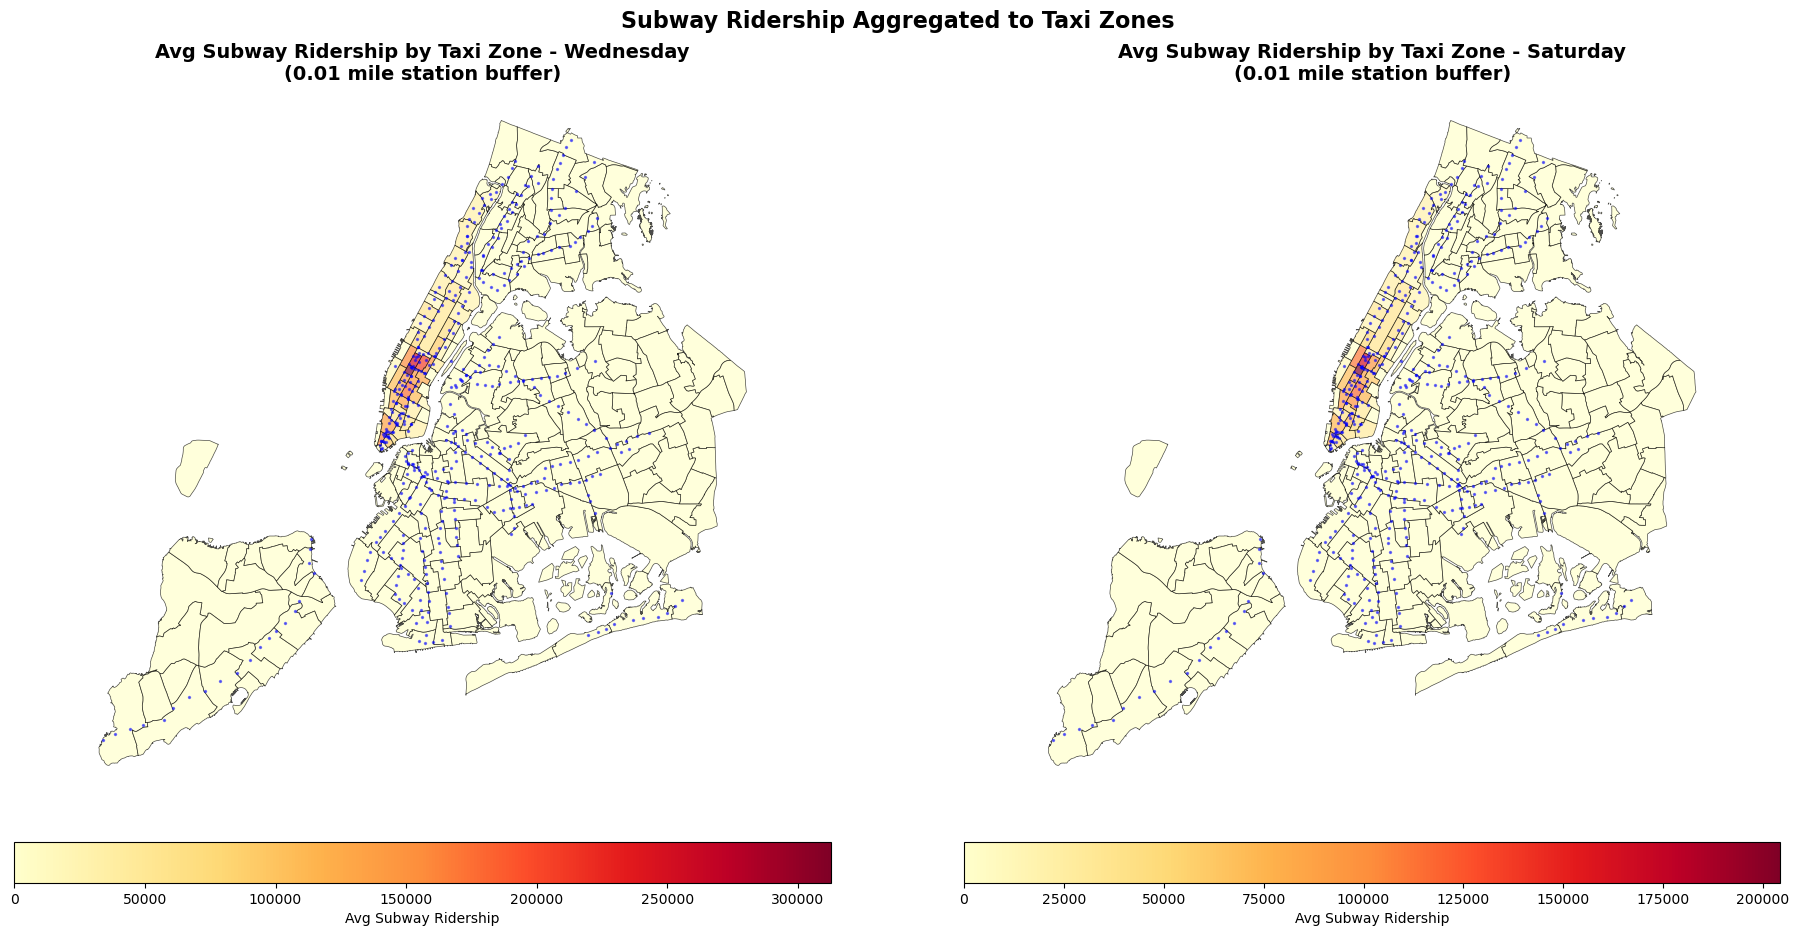


SUMMARY STATISTICS

Wednesday average total subway ridership: 3,966,634
Saturday average total subway ridership: 2,538,267
Saturday/Wednesday ratio: 0.64

TOP 10 ZONES BY SUBWAY RIDERSHIP

Wednesday:
  Garment District (Manhattan): 312,688 avg daily riders
  Times Sq/Theatre District (Manhattan): 248,846 avg daily riders
  Midtown Center (Manhattan): 208,702 avg daily riders
  Union Sq (Manhattan): 174,324 avg daily riders
  World Trade Center (Manhattan): 157,991 avg daily riders

Saturday:
  Garment District (Manhattan): 204,310 avg daily riders
  Times Sq/Theatre District (Manhattan): 163,304 avg daily riders
  Union Sq (Manhattan): 115,933 avg daily riders
  Clinton East (Manhattan): 111,172 avg daily riders
  Greenwich Village North (Manhattan): 98,313 avg daily riders

MANHATTAN-ONLY VIEW


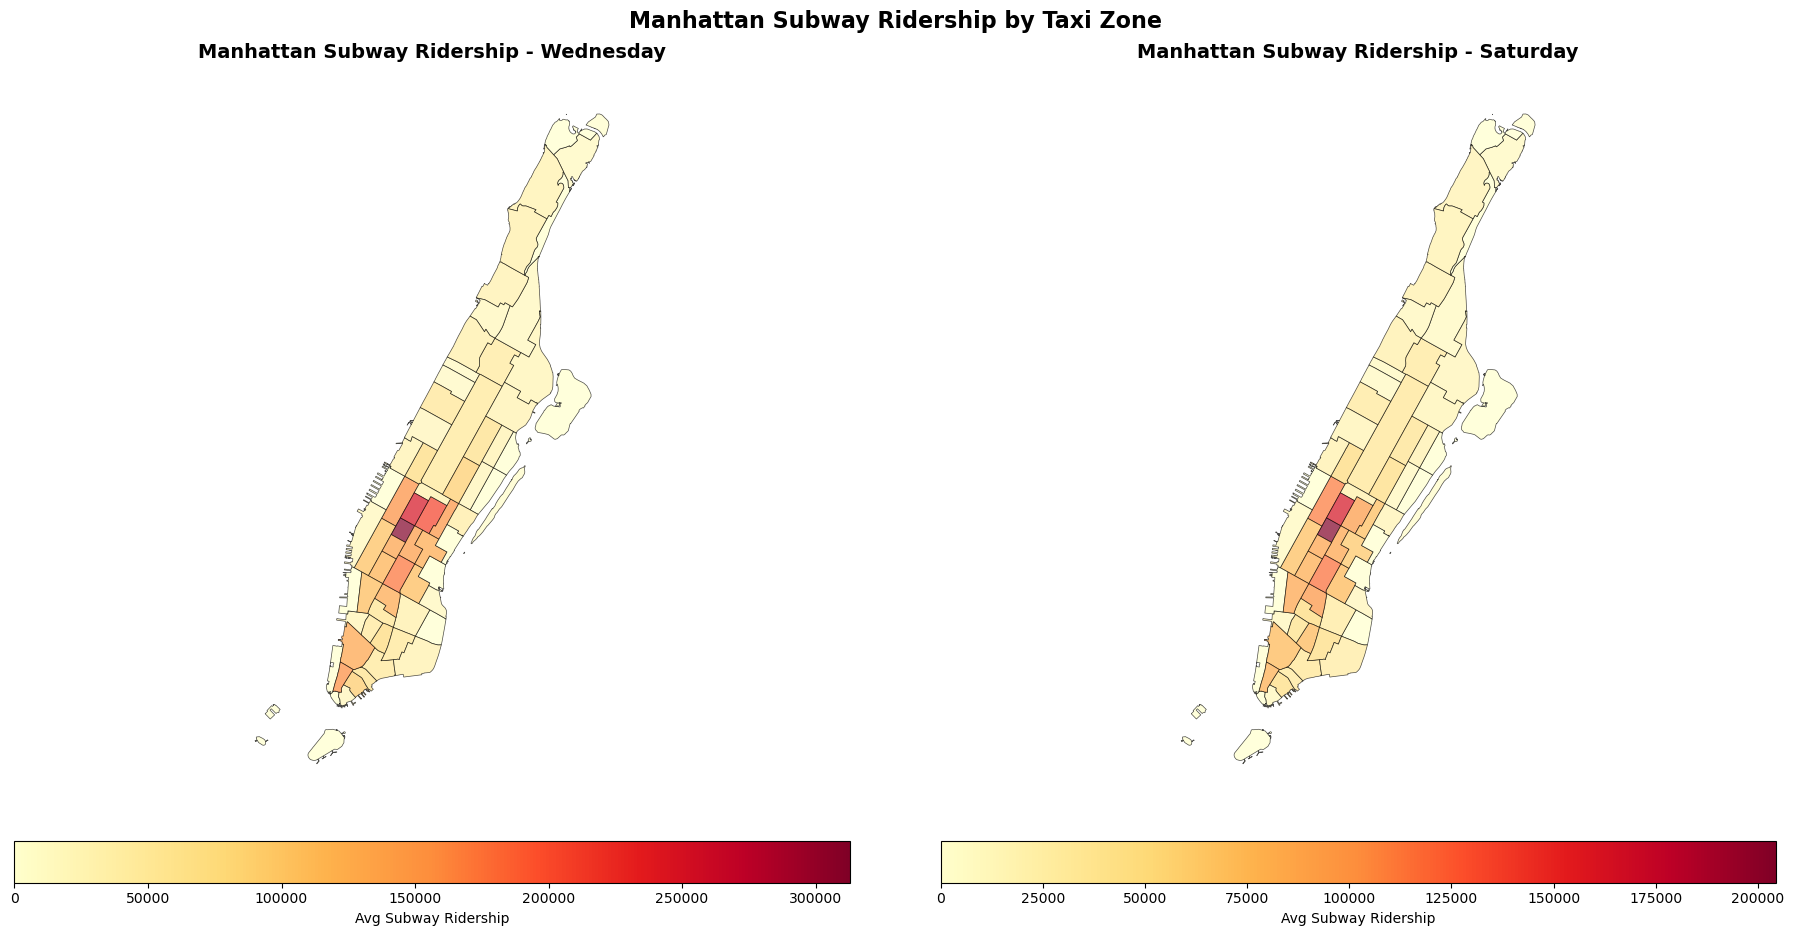

In [41]:
print("=" * 60)
print("MAPPING SUBWAY STATIONS TO TAXI ZONES")
print("=" * 60)

# Check taxi zones columns
print("\nTaxi zones columns:")
print(taxi_zones_gdf.columns.tolist())

# 1. Prepare stations GeoDataFrame
stations_gdf = subway_stations_gdf.copy()

# Check and set CRS if needed
if stations_gdf.crs is None:
    stations_gdf = stations_gdf.set_crs('EPSG:4326')

# Convert to a projected CRS for accurate buffering (meters)
stations_gdf = stations_gdf.to_crs('EPSG:3857')
taxi_zones_gdf = taxi_zones_gdf.to_crs('EPSG:3857')

# 2. Set buffer distance
buffer_distance_miles = 0.01
buffer_distance_meters = buffer_distance_miles * 1609.34

# Create buffers - store in a separate column
stations_gdf['buffer_geom'] = stations_gdf.geometry.buffer(buffer_distance_meters)

print(f"\nBuffer distance: {buffer_distance_miles} miles ({buffer_distance_meters:.0f} meters)")
print(f"Total stations: {len(stations_gdf)}")

# 3. Spatial join using the buffer geometry
stations_buffer_gdf = stations_gdf[['Complex ID', 'Stop Name', 'Borough']].copy()
stations_buffer_gdf = stations_buffer_gdf.set_geometry(stations_gdf['buffer_geom'])
stations_buffer_gdf.crs = stations_gdf.crs

station_zone_mapping = gpd.sjoin(
    stations_buffer_gdf,
    taxi_zones_gdf,
    how='left',
    predicate='intersects'
)

# Drop duplicate station-zone combinations
station_zone_mapping = station_zone_mapping.drop_duplicates(subset=['Complex ID', 'locationid'])

print(f"\nMapping results:")
print(f"  Stations mapped to zones: {station_zone_mapping['Complex ID'].nunique()}")
print(f"  Unique zone-station pairs: {len(station_zone_mapping)}")
print(f"\nMapping columns:")
print(station_zone_mapping.columns.tolist())

# 4. Prepare MTA ridership data
mta_df['date'] = pd.to_datetime(mta_df['date'])
mta_df['station_complex_id'] = mta_df['station_complex_id'].astype(str)
station_zone_mapping['Complex ID'] = station_zone_mapping['Complex ID'].astype(str)

# Merge ridership with zone mapping
station_zone_ridership = station_zone_mapping.merge(
    mta_df,
    left_on='Complex ID',
    right_on='station_complex_id',
    how='left'
)

# 5. Aggregate ridership by taxi zone and date
zone_daily_ridership = station_zone_ridership.groupby(['date', 'locationid']).agg({
    'ridership': 'sum'
}).reset_index()

print(f"\nRidership aggregated to {zone_daily_ridership['locationid'].nunique()} zones")

# 6. Add day of week
zone_daily_ridership['date'] = pd.to_datetime(zone_daily_ridership['date'])
zone_daily_ridership['day_of_week'] = zone_daily_ridership['date'].dt.day_name()

# 7. Filter for Wednesday and Saturday
wednesday_zone_rides = zone_daily_ridership[zone_daily_ridership['day_of_week'] == 'Wednesday']
saturday_zone_rides = zone_daily_ridership[zone_daily_ridership['day_of_week'] == 'Saturday']

# Calculate average ridership by zone for each day
wednesday_avg = wednesday_zone_rides.groupby('locationid').agg({
    'ridership': 'mean'
}).reset_index()

saturday_avg = saturday_zone_rides.groupby('locationid').agg({
    'ridership': 'mean'
}).reset_index()

# 8. Merge with taxi zones for mapping
zones_wed = taxi_zones_gdf.merge(
    wednesday_avg,
    on='locationid',
    how='left'
)
zones_wed['ridership'] = zones_wed['ridership'].fillna(0)

zones_sat = taxi_zones_gdf.merge(
    saturday_avg,
    on='locationid',
    how='left'
)
zones_sat['ridership'] = zones_sat['ridership'].fillna(0)

# Check merged data columns
print("\nMerged zones_wed columns:")
print(zones_wed.columns.tolist())

# 9. Create heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Wednesday heatmap
ax1 = axes[0]
zones_wed.plot(column='ridership',
               ax=ax1,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black',
               linewidth=0.5,
               alpha=0.7,
               legend_kwds={'label': 'Avg Subway Ridership',
                           'orientation': 'horizontal',
                           'shrink': 0.8,
                           'pad': 0.05})

# Plot subway stations
stations_gdf.plot(ax=ax1, color='blue', markersize=2, alpha=0.5, label='Subway Stations')

ax1.set_title(f'Avg Subway Ridership by Taxi Zone - Wednesday\n({buffer_distance_miles} mile station buffer)',
              fontsize=14, fontweight='bold')
ax1.set_axis_off()

# Saturday heatmap
ax2 = axes[1]
zones_sat.plot(column='ridership',
               ax=ax2,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black',
               linewidth=0.5,
               alpha=0.7,
               legend_kwds={'label': 'Avg Subway Ridership',
                           'orientation': 'horizontal',
                           'shrink': 0.8,
                           'pad': 0.05})

# Plot subway stations
stations_gdf.plot(ax=ax2, color='blue', markersize=2, alpha=0.5, label='Subway Stations')

ax2.set_title(f'Avg Subway Ridership by Taxi Zone - Saturday\n({buffer_distance_miles} mile station buffer)',
              fontsize=14, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Subway Ridership Aggregated to Taxi Zones', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 10. Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print(f"\nWednesday average total subway ridership: {wednesday_avg['ridership'].sum():,.0f}")
print(f"Saturday average total subway ridership: {saturday_avg['ridership'].sum():,.0f}")
print(f"Saturday/Wednesday ratio: {saturday_avg['ridership'].sum() / wednesday_avg['ridership'].sum():.2f}")

# 11. Try to get zone names if they exist
if 'zone' in zones_wed.columns and 'borough' in zones_wed.columns:
    print("\n" + "=" * 60)
    print("TOP 10 ZONES BY SUBWAY RIDERSHIP")
    print("=" * 60)

    print("\nWednesday:")
    top_wed = zones_wed.nlargest(5, 'ridership')[['zone', 'borough', 'ridership']]
    for idx, row in top_wed.iterrows():
        print(f"  {row['zone']} ({row['borough']}): {row['ridership']:,.0f} avg daily riders")

    print("\nSaturday:")
    top_sat = zones_sat.nlargest(5, 'ridership')[['zone', 'borough', 'ridership']]
    for idx, row in top_sat.iterrows():
        print(f"  {row['zone']} ({row['borough']}): {row['ridership']:,.0f} avg daily riders")
else:
    print("\nZone names not available - showing location IDs instead:")
    print("\nWednesday top zones:")
    top_wed = zones_wed.nlargest(5, 'ridership')[['locationid', 'ridership']]
    for idx, row in top_wed.iterrows():
        print(f"  Zone {row['locationid']}: {row['ridership']:,.0f} avg daily riders")
    
    print("\nSaturday top zones:")
    top_sat = zones_sat.nlargest(5, 'ridership')[['locationid', 'ridership']]
    for idx, row in top_sat.iterrows():
        print(f"  Zone {row['locationid']}: {row['ridership']:,.0f} avg daily riders")

# 12. Manhattan-only view (if borough column exists)
if 'borough' in zones_wed.columns:
    print("\n" + "=" * 60)
    print("MANHATTAN-ONLY VIEW")
    print("=" * 60)

    manhattan_wed = zones_wed[zones_wed['borough'] == 'Manhattan']
    manhattan_sat = zones_sat[zones_sat['borough'] == 'Manhattan']

    if len(manhattan_wed) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))

        # Manhattan Wednesday
        ax1 = axes[0]
        manhattan_wed.plot(column='ridership',
                           ax=ax1,
                           legend=True,
                           cmap='YlOrRd',
                           edgecolor='black',
                           linewidth=0.5,
                           alpha=0.7,
                           legend_kwds={'label': 'Avg Subway Ridership',
                                       'orientation': 'horizontal',
                                       'shrink': 0.8,
                                       'pad': 0.05})

        # Plot only Manhattan stations
        manhattan_stations = stations_gdf[stations_gdf['Borough'] == 'Manhattan']
        if len(manhattan_stations) > 0:
            manhattan_stations.plot(ax=ax1, color='blue', markersize=3, alpha=0.5, label='Subway Stations')

        ax1.set_title('Manhattan Subway Ridership - Wednesday', fontsize=14, fontweight='bold')
        ax1.set_axis_off()

        # Manhattan Saturday
        ax2 = axes[1]
        manhattan_sat.plot(column='ridership',
                           ax=ax2,
                           legend=True,
                           cmap='YlOrRd',
                           edgecolor='black',
                           linewidth=0.5,
                           alpha=0.7,
                           legend_kwds={'label': 'Avg Subway Ridership',
                                       'orientation': 'horizontal',
                                       'shrink': 0.8,
                                       'pad': 0.05})

        if len(manhattan_stations) > 0:
            manhattan_stations.plot(ax=ax2, color='blue', markersize=3, alpha=0.5, label='Subway Stations')

        ax2.set_title('Manhattan Subway Ridership - Saturday', fontsize=14, fontweight='bold')
        ax2.set_axis_off()

        plt.suptitle('Manhattan Subway Ridership by Taxi Zone', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()